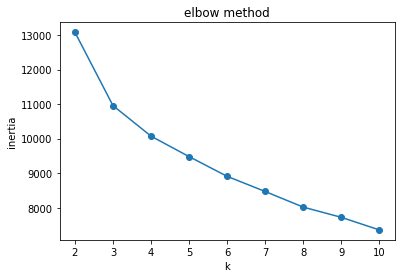

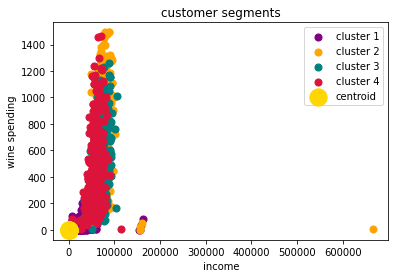

         ID   Income  MntWines  MntMeatProducts  cluster
0      5524  58138.0       635              546        2
1      2174  46344.0        11                6        0
2      4141  71613.0       426              127        3
3      6182  26646.0        11               20        0
4      5324  58293.0       173              118        3
...     ...      ...       ...              ...      ...
2235  10870  61223.0       709              182        2
2236   4001  64014.0       406               30        3
2237   7270  56981.0       908              217        3
2238   8235  69245.0       428              214        3
2239   9405  52869.0        84               61        0

[2240 rows x 5 columns]


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


data = pd.read_csv('/kaggle/input/customer-personality-analysis/marketing_campaign.csv', sep = '\t')


cols = [
    'Income',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases'
]


cust = data[cols].copy()

cust = cust.fillna(cust.median())


scaler = StandardScaler()

x = scaler.fit_transform(cust)


inertia = []

for k in range(2, 11):
    
    model = KMeans(n_clusters = k,
                   init = 'k-means++',
                   random_state = 42)
    
    model.fit(x)
    
    inertia.append(model.inertia_)


plt.plot(range(2, 11), inertia, marker = 'o')

plt.title('elbow method')
plt.xlabel('k')
plt.ylabel('inertia')

plt.show()


kmeans = KMeans(n_clusters = 4,
                init = 'k-means++',
                random_state = 42)

labels = kmeans.fit_predict(x)

data['cluster'] = labels


colors = ['purple', 'orange', 'teal', 'crimson']


for i in range(4):
    
    plt.scatter(cust['Income'][labels == i],
                cust['MntWines'][labels == i],
                s = 50,
                c = colors[i],
                label = f'cluster {i+1}')


plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s = 300,
            c = 'gold',
            label = 'centroid')


plt.title('customer segments')
plt.xlabel('income')
plt.ylabel('wine spending')

plt.legend()

plt.show()


print(data[['ID', 'Income', 'MntWines', 'MntMeatProducts', 'cluster']])